# Heat warning impacts

In [ ]:
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import xarray as xr
import xvec  # noqa: F401
from meteora import utils as meteora_utils

from swiss_lcd_heatwaves import heat_warnings

sns.set_style("whitegrid")


def get_ts_df_dict(aws_ts_cube_filepath, lcd_ts_df_filepath, cor_ts_df_filepath):
    """Get a dictionary of time series data frames."""
    # AWS
    aws_ts_cube = xr.open_dataset(aws_ts_cube_filepath).xvec.decode_cf()
    aws_ts_df = (
        aws_ts_cube["temperature"]
        .set_index(geometry="station_id")
        .rename(geometry="station_id")
        .to_pandas()
    )

    # LCD (raw)
    lcd_ts_df = pd.read_csv(lcd_ts_df_filepath, index_col="time", parse_dates=["time"])

    # LCD (corrected)
    cor_ts_df = pd.read_csv(cor_ts_df_filepath, index_col="time", parse_dates=["time"])

    # put them all into a dict and return it
    return {"AWS": aws_ts_df, "LCD$_{raw}$": lcd_ts_df, "LCD$_{cor}$": cor_ts_df}

In [ ]:
aws_ts_cube_filepaths = [
    "../data/interim/bern-aws-ts-cube.nc",
    "../data/interim/zurich-aws-ts-cube.nc",
]
lcd_ts_df_filepaths = [
    "../data/interim/bern-lcd-ts-df.csv",
    "../data/interim/zurich-lcd-ts-df.csv",
]
lcd_stations_gdf_filepaths = [
    "../data/interim/bern-lcd-stations.gpkg",
    "../data/interim/zurich-lcd-stations.gpkg",
]
cor_ts_df_filepaths = [
    "../data/interim/bern-cor-ts-df.csv",
    "../data/interim/zurich-cor-ts-df.csv",
]
agglom_names = ["Bern", "Zurich"]

dst_fig_n_heat_warnings_filepath = "../reports/figures/n-heat-warnings.pdf"
dst_fig_heat_warnings_daily_cycle_filepath = (
    "../reports/figures/heat-warnings-daily-cycle.pdf"
)
dst_fig_t_station_type_maps_filepath = "../reports/figures/t-station-type-maps.png"
savefig_kwargs = {"dpi": 300, "bbox_inches": "tight"}

In [ ]:
# load stations locations
aws_gdf = pd.concat(
    [
        xr.open_dataset(aws_ts_cube_filepath)
        .xvec.decode_cf()["station_id"]
        .xvec.to_geopandas()
        for aws_ts_cube_filepath in aws_ts_cube_filepaths
    ]
)
lcd_gdf = pd.concat(
    [
        gpd.read_file(lcd_stations_gdf_filepath)
        for lcd_stations_gdf_filepath in lcd_stations_gdf_filepaths
    ]
)

stations_gser = pd.concat(
    [
        _stations_gdf.set_index("station_id")["geometry"]
        for _stations_gdf in [aws_gdf, lcd_gdf]
    ]
)

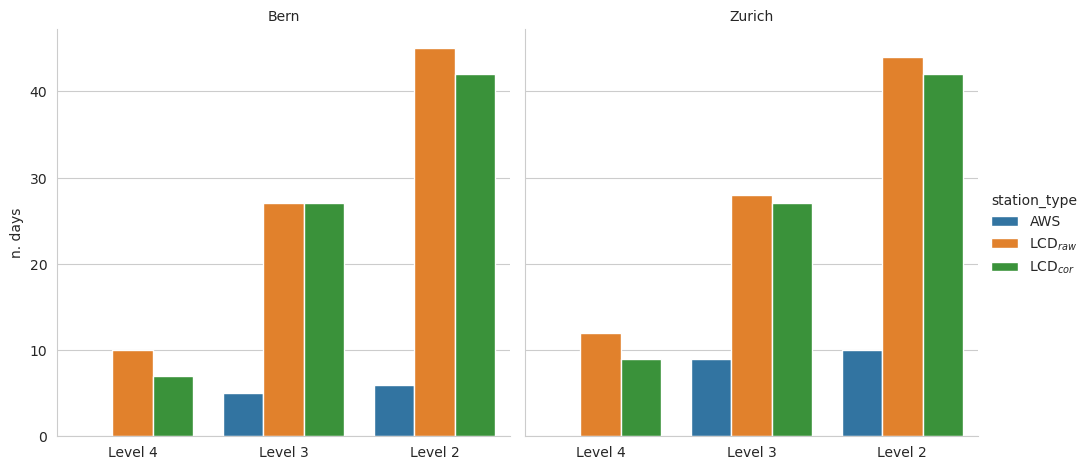

In [ ]:
ts_df_dict = {}
heatwave_periods_dict = {}
heat_days_dfs = []
for aws_ts_cube_filepath, lcd_ts_df_filepath, cor_ts_df_filepath, agglom_name in zip(
    aws_ts_cube_filepaths, lcd_ts_df_filepaths, cor_ts_df_filepaths, agglom_names
):
    _ts_df_dict = get_ts_df_dict(
        aws_ts_cube_filepath, lcd_ts_df_filepath, cor_ts_df_filepath
    )
    ts_df_dict[agglom_name] = _ts_df_dict
    _heatwave_periods_dict = heat_warnings.get_heatwave_periods_dict(_ts_df_dict)
    heatwave_periods_dict[agglom_name] = _heatwave_periods_dict
    heat_days_dfs.append(
        heat_warnings.get_heat_days_df(_heatwave_periods_dict).assign(
            **{"agglom_name": agglom_name}
        )
    )
heat_days_df = pd.concat(heat_days_dfs)

# g = sns.FacetGrid(
#     heat_days_df,
#     col="level",
#     # hue="station_type"
# )
# g.map_dataframe(sns.barplot, x="year", y="n. days",     hue="station_type")
# g.add_legend()
g = sns.catplot(
    heat_days_df,
    kind="bar",
    # x="year",
    x="level",
    y="n. days",
    hue="station_type",
    # col="level",
    # row="agglom_name",
    col="agglom_name",
    estimator="sum",
    errorbar=None,
)
g.set_titles(col_template="{col_name}", row_template="{row_name}")
# for ax, agglom_name in zip(g.axes[:, 0], heat_days_df["agglom_name"].unique()):
#     ax.set_ylabel(
#         agglom_name, fontweight="bold", rotation=0, ha="right", va="center"
#     )
g.set_xlabels(label="")
# sns.move_legend(
#     g,
#     "lower center",
#     bbox_to_anchor=(0.5, 0),
#     ncol=heat_days_df["station_type"].nunique(),
#     title=None,
#     frameon=False,
# )
g.figure.savefig(dst_fig_n_heat_warnings_filepath, **savefig_kwargs)

<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1239337/564401859.py:2: SyntaxWarning: invalid escape sequence '\c'
  value_name = "T$^{\circ}$ [C]"


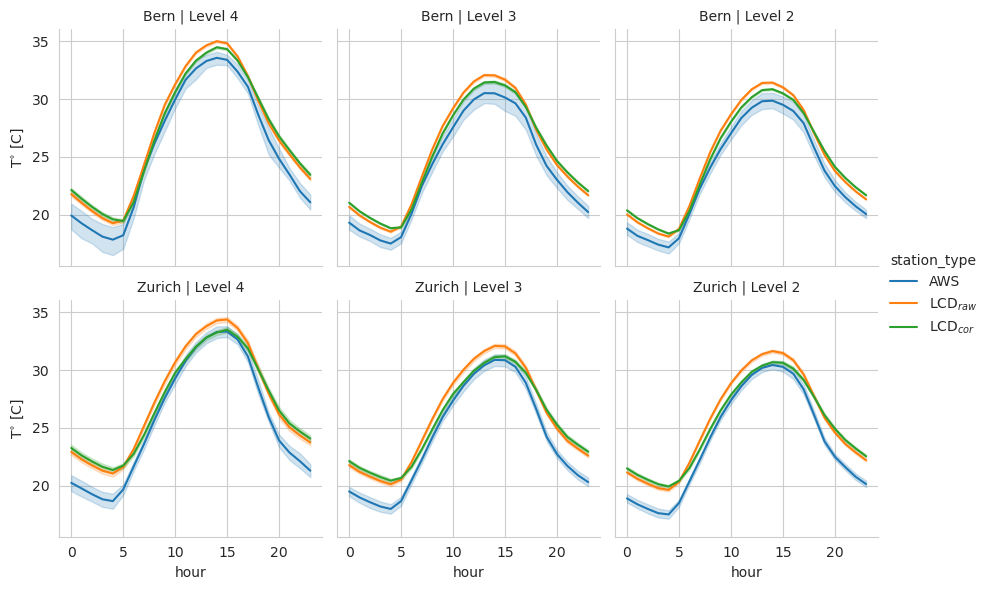

In [ ]:
col_wrap = 2
value_name = "T$^{\circ}$ [C]"
var_name = "station_type"
# ref_level = "Level 4"
ref_station_type = "LCD$_{cor}$"

plot_df = pd.concat(
    [
        pd.concat(
            [
                pd.concat(
                    [
                        meteora_utils.get_heatwave_ts_df(
                            ts_df,
                            heatwave_periods=[
                                period
                                for level_periods in level_periods_dict[
                                    ref_station_type
                                ].values()
                                for period in level_periods
                            ],
                        )
                        .rename_axis(columns="station_id")
                        .stack()
                        .rename(station_type)
                        for station_type, ts_df in ts_df_dict[agglom_name].items()
                    ],
                    axis="columns",
                ).assign(**{"level": level})
                for level, level_periods_dict in periods_dict.items()
            ]
        )
        .reset_index()
        .melt(
            id_vars=["heatwave", "time", "station_id", "level"],
            var_name=var_name,
            value_name=value_name,
        )
        .assign(**{"agglom_name": agglom_name})
        for agglom_name, periods_dict in heatwave_periods_dict.items()
    ]
).dropna()
plot_df = plot_df.assign(**{"hour": plot_df["time"].dt.hour})
g = sns.FacetGrid(plot_df, col="level", row="agglom_name", hue=var_name)
g.map(sns.lineplot, "hour", value_name)
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.add_legend()
# sns.move_legend(
#     g,
#     "lower center",
#     bbox_to_anchor=(0.5, 1),
#     ncol=heat_days_df["station_type"].nunique(),
#     title=None,
#     frameon=False,
# )
g.figure.savefig(dst_fig_heat_warnings_daily_cycle_filepath, **savefig_kwargs)

{'Bern': Timestamp('2024-07-19 12:00:00'), 'Zurich': Timestamp('2023-08-21 11:00:00')}


/tmp/ipykernel_1239337/1217152809.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  g.figure.tight_layout(w_pad=4)


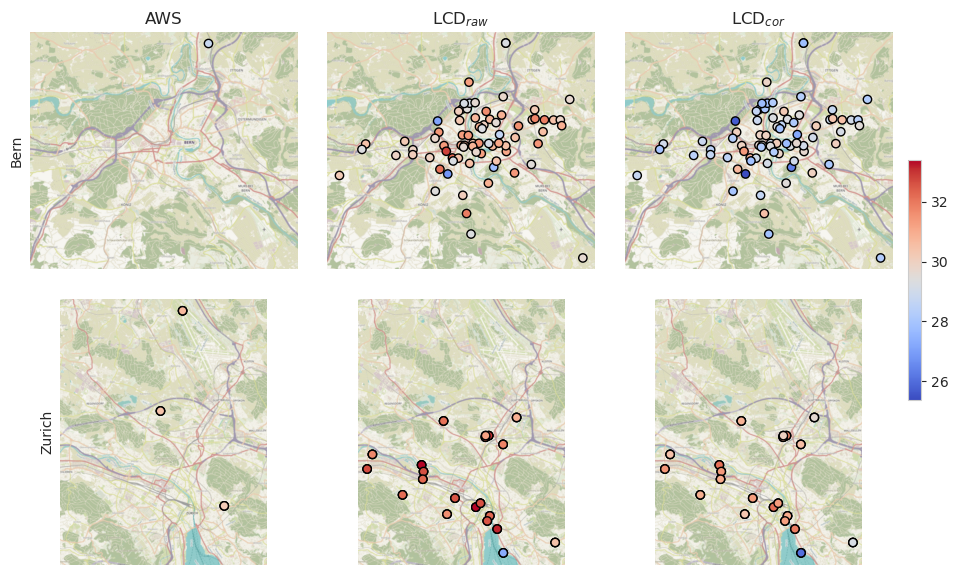

In [ ]:
def _get_station_ts_ser(station_df, station_type):
    return station_df[station_df["station_type"] == station_type].set_index("time")[
        value_name
    ]


def _get_time_max_sub(station_df):
    # try:
    return (
        _get_station_ts_ser(station_df, "LCD$_{raw}$").sub(
            _get_station_ts_ser(station_df, "LCD$_{cor}$")
        )
        # .idxmax()
    )
    # except ValueError:
    #     return np.nan


max_diff_dict = {
    agglom_name: agglom_plot_df.groupby("station_id")
    .apply(_get_time_max_sub, include_groups=False)
    .reset_index()
    .pivot_table(index="time", values=value_name, columns="station_id")
    .mean(axis="columns")
    .idxmax()
    for agglom_name, agglom_plot_df in plot_df.groupby("agglom_name")
}
print(max_diff_dict)
agglom_plot_gdfs = []
for agglom_name, agglom_plot_df in plot_df.groupby("agglom_name"):
    # hottest_heatwave = (
    #     agglom_plot_df[agglom_plot_df["station_type"] == ref_station_type]
    #     .groupby("heatwave")[value_name]
    #     .mean()
    #     .idxmax()
    # )
    # _agglom_plot_gdf = (
    #     # agglom_plot_df[agglom_plot_df["heatwave"] == hottest_heatwave]
    #     agglom_plot_df.groupby(["station_id", "station_type"])[value_name]
    #     .max()
    #     .reset_index()
    # )
    _agglom_plot_gdf = agglom_plot_df[
        agglom_plot_df["time"] == max_diff_dict[agglom_name]
    ]
    _agglom_plot_gdf = gpd.GeoDataFrame(
        _agglom_plot_gdf,
        geometry=_agglom_plot_gdf["station_id"].map(stations_gser),
        crs=stations_gser.crs,
    )
    agglom_plot_gdfs.append(_agglom_plot_gdf.assign(**{"agglom_name": agglom_name}))
# assemble into single geo-data frame
agglom_plot_gdf = pd.concat(agglom_plot_gdfs)

# prepare facet grid
# col_order= ["AWS", "LCD", "LCD'"]
# agglom_plot_gdf = agglom_plot_gdf.sort_values("station_type")
with sns.axes_style("white"):
    # g = sns.FacetGrid(agglom_plot_gdf, col="station_type")
    g = sns.FacetGrid(
        agglom_plot_gdf,
        row="agglom_name",
        col="station_type",
        sharex="row",
        sharey="row",
        # col_order=col_order
        # margin_titles=True
    )

# get min and max values
vmin = agglom_plot_gdf[value_name].min()
vmax = agglom_plot_gdf[value_name].max()


def _gdf_plot(data, **kwargs):
    ax = plt.gca()
    data.plot(
        value_name, ax=ax, vmin=vmin, vmax=vmax, cmap="coolwarm", edgecolor="black"
    )
    # ACHTUNG: for some reason, adding the basemap here results in wrong axis limits
    # cx.add_basemap(ax, crs=stations_gser.crs, attribution=False)


g.map_dataframe(_gdf_plot)

# add base maps
for ax in g.axes.flat:
    cx.add_basemap(ax, crs=stations_gser.crs, attribution=False)

# remove axes lines, ticks and labels
for ax in g.axes.flat:
    # ax.set_axis_off()
    ax.axes.get_xaxis().set_visible(False)
    ax.axes.get_yaxis().set_ticks([])
    for spine in ["bottom", "left"]:
        ax.spines[spine].set_visible(False)

# fix axes titles
g.set_titles(col_template="{col_name}", row_template="{row_name}")
for ax_row in g.axes:
    ax_row[0].set_ylabel(ax_row[0].get_title().split(" | ")[0])
for ax in g.axes[0]:
    ax.set_title(ax.get_title().split(" | ")[1])
for ax in g.axes[1]:
    ax.set_title("")


# add colorbar
im = plt.gca().get_children()[0]
cbar_ax = g.figure.add_axes([1, 0.3, 0.015, 0.4])
g.figure.colorbar(im, cax=cbar_ax)

# save the figure
g.figure.tight_layout(w_pad=4)
g.figure.savefig(
    dst_fig_t_station_type_maps_filepath,
    **savefig_kwargs,
)